In [1]:
!git clone https://github.com/Anshr23/EmotiTrack.git

Cloning into 'EmotiTrack'...
remote: Enumerating objects: 1506, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 1506 (delta 0), reused 0 (delta 0), pack-reused 1504 (from 2)
Receiving objects: 100% (1506/1506), 937.42 MiB | 23.04 MiB/s, done.
Resolving deltas: 100% (95/95), done.
Updating files: 100% (164/164), done.


In [2]:
cd EmotiTrack/

/content/EmotiTrack


In [3]:
!pip install soundfile librosa scikit-learn matplotlib seaborn

In [4]:
import soundfile
import numpy as np
import librosa
import glob
import os
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Custom emotion mapping
custom_emotions_map = {
    'satisfied': 0,
    'unsatisfied': 1,
    'average': 2
}
custom_emotion_names = ['satisfied', 'unsatisfied', 'average']

In [31]:
def extract_feature(file_name, **kwargs):
    """
    Extracts advanced features (mean and standard deviation) from an audio file.
    """
    mfcc = kwargs.get("mfcc")
    chroma = kwargs.get("chroma")
    mel = kwargs.get("mel")

    with soundfile.SoundFile(file_name) as sound_file:
        X = sound_file.read(dtype="float32")
        sample_rate = sound_file.samplerate

        result = np.array([])

        if mfcc:
            mfccs = librosa.feature.mfcc(y=X, sr=sample_rate, n_mfcc=40).T
            # Get both mean and standard deviation of MFCCs
            result = np.hstack((result, np.mean(mfccs, axis=0), np.std(mfccs, axis=0)))

        if chroma:
            stft = np.abs(librosa.stft(X))
            chroma_feat = librosa.feature.chroma_stft(S=stft, sr=sample_rate).T
            # Get both mean and standard deviation of Chroma
            result = np.hstack((result, np.mean(chroma_feat, axis=0), np.std(chroma_feat, axis=0)))

        if mel:
            mel_feat = librosa.feature.melspectrogram(y=X, sr=sample_rate).T
            # Get both mean and standard deviation of Mel Spectrogram
            result = np.hstack((result, np.mean(mel_feat, axis=0), np.std(mel_feat, axis=0)))

    return result

In [32]:
def load_custom_data(data_root_path, test_size=0.25):
    x, y = [], []
    for emotion_folder_name in custom_emotions_map.keys():
        current_folder_path = os.path.join(data_root_path, emotion_folder_name)
        for file_path in glob.glob(os.path.join(current_folder_path, '*.wav')):
            label_integer = custom_emotions_map[emotion_folder_name]
            try:
                feature = extract_feature(file_path, mfcc=True, chroma=True, mel=True)
                x.append(feature)
                y.append(label_integer)
            except Exception as e:
                print(f"Skipping {file_path}: {e}")
    X = np.array(x)
    Y = np.array(y)
    return train_test_split(X, Y, test_size=test_size, random_state=9, stratify=Y)

In [33]:
data_root_path = 'my_audio'  # Make sure this matches your folder name
X_train, X_test, y_train, y_test = load_custom_data(data_root_path, test_size=0.25)

print("[+] Number of training samples:", X_train.shape[0])
print("[+] Number of testing samples:", X_test.shape[0])
print("[+] Number of features:", X_train.shape[1])

Skipping my_audio/average/recording-173-25233357-441627496502.ulaw(1).wav: Error opening 'my_audio/average/recording-173-25233357-441627496502.ulaw(1).wav': Error in WAV file. No 'data' chunk marker.
[+] Number of training samples: 111
[+] Number of testing samples: 38
[+] Number of features: 360


In [34]:
# model_params = {
#     'alpha': 0.01,
#     'batch_size': 256,
#     'epsilon': 1e-08,
#     'hidden_layer_sizes': (300,),
#     'learning_rate': 'adaptive',
#     'max_iter': 500,
# }
# model_params = {
#     'alpha': 0.01,
#     'batch_size': 256,  # Try reducing this to 64 or 32
#     'hidden_layer_sizes': (300,),  # Try (300, 150, 50)
#     'max_iter': 500,  # Increase to 1000
# }
model_params = {
    'alpha': 0.001,  # Reduced regularization
    'batch_size': 32,  # Smaller batch size
    'hidden_layer_sizes': (200, 100),  # Two layers instead of one
    'learning_rate': 'adaptive',
    'max_iter': 1000,  # More iterations
    'early_stopping': True,  # Stop if not improving
}
model = MLPClassifier(**model_params)

print("[*] Training the model...")
model.fit(X_train, y_train)

[*] Training the model...


MLPClassifier(alpha=0.001, batch_size=32, early_stopping=True,
              hidden_layer_sizes=(200, 100), learning_rate='adaptive',
              max_iter=1000)

Training Random Forest...
Random Forest Accuracy: 47.37%

Training SVM...
SVM Accuracy: 31.58%

Using Random Forest (Accuracy: 47.37%)

Classification Report:
              precision    recall  f1-score   support

   satisfied       0.42      0.62      0.50        13
 unsatisfied       0.50      0.33      0.40        12
     average       0.55      0.46      0.50        13

    accuracy                           0.47        38
   macro avg       0.49      0.47      0.47        38
weighted avg       0.49      0.47      0.47        38



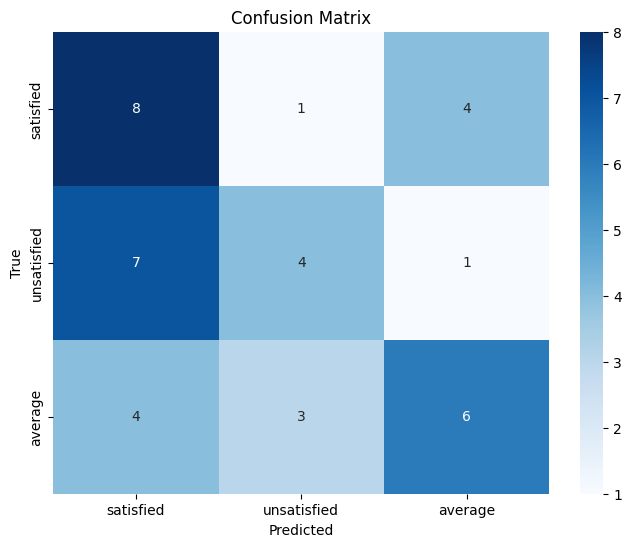

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Try Random Forest first (often works better with small datasets)
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2%}")

# Try SVM
print("\nTraining SVM...")
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Evaluate
y_pred_svm = svm_model.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.2%}")

# Compare and use the better model
if accuracy_rf > accuracy_svm:
    model = rf_model
    y_pred = y_pred_rf
    print(f"\nUsing Random Forest (Accuracy: {accuracy_rf:.2%})")
else:
    model = svm_model
    y_pred = y_pred_svm
    print(f"\nUsing SVM (Accuracy: {accuracy_svm:.2%})")

# Show detailed results
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=custom_emotion_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=custom_emotion_names, yticklabels=custom_emotion_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [46]:
# Change the path below to any .wav file you want to test
test_file_path = "my_audio/random/audio 9.wav"  # Change as needed

test_feature = extract_feature(test_file_path, mfcc=True, chroma=True, mel=True)
test_feature_reshaped = np.expand_dims(test_feature, axis=0)
prediction = model.predict(test_feature_reshaped)[0]
predicted_emotion = custom_emotion_names[prediction]
print(f"The predicted emotion for '{os.path.basename(test_file_path)}' is: {predicted_emotion}")

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(1, 360), dtype=float32). Expected shape (None, 19236, 40), but input has incompatible shape (1, 360)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 360), dtype=float32)
  • training=False
  • mask=None

In [ ]:
import pickle
if not os.path.isdir("result"):
    os.mkdir("result")
pickle.dump(model, open("result/mlp_classifier.model", "wb"))

In [19]:
import glob
import os

for emotion in ['satisfied', 'unsatisfied', 'average']:
    files = glob.glob(f'my_audio/{emotion}/*.wav')
    print(f"{emotion}: {len(files)} files")

satisfied: 52 files
unsatisfied: 48 files
average: 50 files


In [39]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D, MaxPooling1D
from tensorflow.keras.utils import to_categorical

In [43]:
from tensorflow.keras.utils import to_categorical

def load_data_for_cnn(data_root_path, test_size=0.2):
    """
    Loads audio, extracts MFCC features, standardizes their length by padding,
    and formats them perfectly for a 1D-CNN.
    """
    x, y = [], []
    max_pad_len = 0

    # --- Pre-scan all files to find the longest sequence of MFCC frames ---
    all_files_to_process = []
    print("Pre-scanning all files to determine max length...")
    for emotion_folder_name in custom_emotions_map.keys():
        folder_path = os.path.join(data_root_path, emotion_folder_name)
        for file_path in glob.glob(os.path.join(folder_path, '*.wav')):
            try:
                audio, sample_rate = librosa.load(file_path, sr=None)
                mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
                if mfccs.shape[1] > max_pad_len:
                    max_pad_len = mfccs.shape[1]
                all_files_to_process.append(file_path)
            except Exception as e:
                print(f"Skipping file during pre-scan {file_path}: {e}")
    print(f"-> Standardizing all audio features to a length of {max_pad_len} frames.")

    # --- Now, process and pad all files to the max frame length ---
    print("\nProcessing and padding all files...")
    for file_path in all_files_to_process:
        try:
            emotion_folder_name = os.path.basename(os.path.dirname(file_path))

            audio, sample_rate = librosa.load(file_path, sr=None)
            # Get MFCCs and transpose them so time is the first dimension
            mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T

            # Pad the sequence of frames to the max length
            pad_width = max_pad_len - mfccs.shape[0]
            padded_mfccs = np.pad(mfccs, pad_width=((0, pad_width), (0, 0)), mode='constant')

            x.append(padded_mfccs)
            y.append(custom_emotions_map[emotion_folder_name])
        except Exception as e:
            print(f"Could not process {file_path}: {e}")

    X = np.array(x)
    Y = np.array(y)

    # One-hot encode the labels for the CNN
    Y_one_hot = to_categorical(Y, num_classes=len(custom_emotions_map))

    return train_test_split(X, Y_one_hot, test_size=test_size, random_state=42, stratify=Y)

In [44]:
# --- IMPORTANT: Call the new function ---
X_train, X_test, y_train, y_test = load_data_for_cnn('my_audio', test_size=0.2)

print("\n--- Data Ready ---")
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Pre-scanning all files to determine max length...


/tmp/ipython-input-43-1653316248.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


-> Standardizing all audio features to a length of 19236 frames.

Processing and padding all files...


/tmp/ipython-input-43-1653316248.py:33: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_path, sr=None)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



--- Data Ready ---
Training data shape: (120, 19236, 40)
Testing data shape: (30, 19236, 40)


In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D, MaxPooling1D

print("Building the 1D-CNN model...")

model = Sequential()
model.add(Conv1D(256, 5, padding='same', activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=4)) # Using a pool size of 4
model.add(Dropout(0.3))

model.add(Conv1D(128, 5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=4)) # Using a pool size of 4
model.add(Dropout(0.3))

# Flatten the output to feed into the Dense layer
model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer - 3 units for 3 emotions
model.add(Dense(len(custom_emotions_map), activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train the model
print("\nTraining the CNN model...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Building the 1D-CNN model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 19236, 256)     │        51,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 4809, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4809, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 4809, 128)      │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 1202, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1202, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 153856)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     9,846,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,062,467 (38.39 MB)

 Trainable params: 10,062,467 (38.39 MB)

 Non-trainable params: 0 (0.00 B)


Training the CNN model...
Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 8s/step - accuracy: 0.3769 - loss: 322.8147 - val_accuracy: 0.3333 - val_loss: 31.0833
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - accuracy: 0.4231 - loss: 34.2084 - val_accuracy: 0.3333 - val_loss: 1.0906
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 8s/step - accuracy: 0.3825 - loss: 1.7609 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 43s 8s/step - accuracy: 0.3973 - loss: 1.0720 - val_accuracy: 0.3333 - val_loss: 1.0982
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 8s/step - accuracy: 0.4740 - loss: 1.0494 - val_accuracy: 0.2667 - val_loss: 1.0995
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 10s/step - accuracy: 0.4517 - loss: 1.0368 - val_accuracy: 0.2667 - val_loss: 1.1054
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 36s 8s/step - accuracy: 0.3519 - loss: 1.1545 - val_accuracy: 0.4333 - val_loss: 1.0982
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 31s 8s/step - accuracy: 0.7094 - loss: 0.9440 - val_accuracy: 0.


Evaluating the model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4000 - loss: 3.0391
Test Accuracy: 40.00%


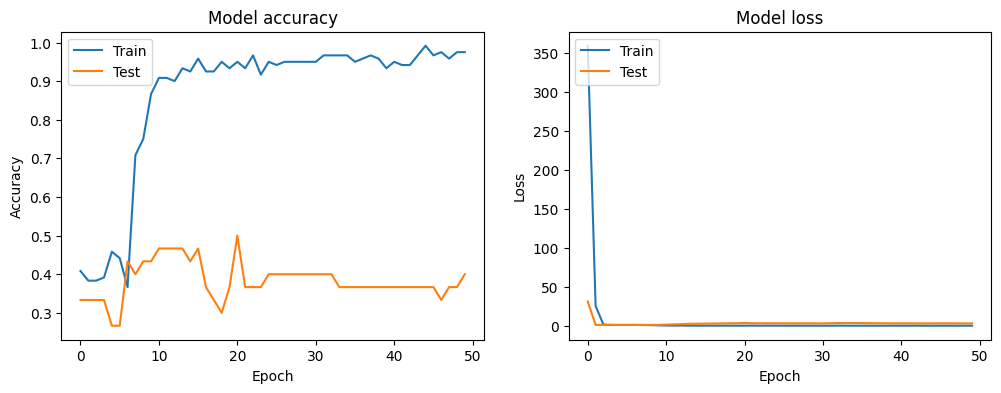

In [47]:
print("\nEvaluating the model...")
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [48]:
# --- IMPORTANT: Change this path to your random audio file ---
# For example, if it's in the main directory: "my_random_song.wav"
# Or if it's in a folder: "my_folder/my_random_song.wav"

  # <-- CHANGE THIS

In [54]:
# This value is crucial - it's the sequence length your model was trained on.
# We get it directly from the shape of your training data.
test_file_path = "my_audio/random/audio 9.wav"

max_pad_len = X_train.shape[1]

def predict_emotion_from_file(model, file_path, max_pad_len):
    """
    Predicts the emotion of a single audio file using the trained CNN model.
    It applies the exact same pre-processing as the training data.
    """
    try:
        # 1. Load the audio file
        audio, sample_rate = librosa.load(file_path, sr=None)

        # 2. Extract MFCCs and transpose
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40).T

        # 3. Pad or truncate the features to match the training data length
        if mfccs.shape[0] > max_pad_len:
            # If the clip is longer, truncate it from the start
            padded_mfccs = mfccs[:max_pad_len, :]
        else:
            # If the clip is shorter, pad it with zeros
            pad_width = max_pad_len - mfccs.shape[0]
            padded_mfccs = np.pad(mfccs, pad_width=((0, pad_width), (0, 0)), mode='constant')

        # 4. Reshape for the model (add a batch dimension)
        reshaped_features = np.expand_dims(padded_mfccs, axis=0)

        # 5. Make the prediction
        prediction_probabilities = model.predict(reshaped_features)[0]

        # 6. Get the class with the highest probability
        predicted_class_index = np.argmax(prediction_probabilities)

        # 7. Convert the index to an emotion name
        predicted_emotion = custom_emotion_names[predicted_class_index]

        return predicted_emotion

    except Exception as e:
        return f"Error processing file: {e}"

# --- Use the function to predict the emotion of your file ---
predicted_label = predict_emotion_from_file(model, test_file_path, max_pad_len)

print("\n--- Prediction Result ---")
print(f"The predicted emotion for the file '{os.path.basename(test_file_path)}' is: {predicted_label.upper()}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step

--- Prediction Result ---
The predicted emotion for the file 'audio 9.wav' is: UNSATISFIED
